# <a id='toc1_'></a>[Dominant Poles - F8 Example](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Dominant Poles - F8 Example](#toc1_)    
- [F-8E Example](#toc2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [29]:
%reload_ext autoreload
%autoreload 2 

In [30]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root / "16_06_Class"))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

print("Basic Material version:", bm.__version__)
print("Control Materials version:", cm.__version__)

bm.setup_environment()
cm.setup_environment()

Basic Material version: 16.06-0.4
Control Materials version: 16.06-0.4
Running Python: 3.12.12
Running SymPy: 1.13.3


In [31]:
import numpy as np
import matplotlib.pyplot as plt

import control as ct
import control.matlab as cmat
from control import balred

from math import pi

import sympy as sp
import scipy.signal as signal
from IPython.display import Math, display

# <a id='toc2_'></a>[F-8E Example](#toc0_)

In [32]:
# original TF
s = ct.tf('s')
num = 964*(s/0.797+1)*(-s/38.8+1)*(s/36+1)
den = ((s/3.59)**2 + 2*(0.28)/3.59*s + 1)*((s/0.032)**2 + 2*(0.18)/0.032*s + 1)
P = num/den
cm.show_tf_latex(P, r"P")

<IPython.core.display.Math object>

In [33]:
# desired reduced order
N_order = 2

In [34]:
# Very Crude Approximation
num_rr = 964
den_rr = ((s/0.032)**2 + 2*(0.18)/0.032*s + 1)
Prr = num_rr/den_rr
cm.show_tf_latex(Prr, r"P_{rr}")

<IPython.core.display.Math object>

In [35]:
#More Advanced Approx covered in 16.30
Pss = ct.tf2ss(P)
if bm.SLYCOT_AVAILABLE:
    print("Using Slycot for balanced reduction")
    Pss_reduced = cmat.balred(Pss, N_order)
else:
    print("No reduction library available, using full order model")
    Pss_reduced = Pss

# remove the near-zero entries to make it look cleaner
Pr = cm.near_zero(ct.ss2tf(Pss_reduced.A,Pss_reduced.B,Pss_reduced.C,Pss_reduced.D))
cm.show_tf_latex(Pr, r"P_{r}")

No reduction library available, using full order model


<IPython.core.display.Math object>

In [36]:
# Functions for PFE decomposition and LaTeX formatting

def fdec(x, n=3):
    """Fixed decimal formatting with absolute value"""
    return f"{abs(float(x)):.{n}f}"

def pfe_full_latex_aligned_fixed(modes, ndec=3):
    terms = []

    for m in modes:

        # -------- REAL POLE TERM --------
        if m['type'] == 'real':
            c = float(m['params']['c'])
            p = float(m['params']['p'])

            sign = "-" if c < 0 else "+"
            term = rf"{sign}\;\frac{{{fdec(c,ndec)}}}{{s + {fdec(p,ndec)}}}"
            terms.append(term)

        # -------- COMPLEX CONJUGATE PAIR --------
        elif m['type'] == 'complex':
            a = float(m['params']['a'])
            b = float(m['params']['b'])
            sigma = float(m['params']['sigma'])
            omega = float(m['params']['omega'])

            sign = "-" if a < 0 else "+"

            # numerator (absolute values only)
            num = f"{fdec(a,ndec)} s"
            if b >= 0:
                num += f" + {fdec(b,ndec)}"
            else:
                num += f" - {fdec(b,ndec)}"

            den = f"(s + {fdec(sigma,ndec)})^2 + {fdec(omega,ndec)}^2"

            term = rf"{sign}\;\frac{{{num}}}{{{den}}}"
            terms.append(term)

    # Remove leading "+"
    terms[0] = terms[0].lstrip("+").strip()

    latex = (
        r"\begin{aligned}"
        r"P(s) &= "
        + r"\\[0.75em] &".join(terms)
        + r"\end{aligned}"
    )

    return latex
    
def pfe_real_modal_mixed(tf, ndigits=6):
    """
    Real modal PFE for a SISO control.TransferFunction.

    Handles:
      - real poles
      - complex conjugate pole pairs

    Returns:
      modes : list of dicts with keys:
        type   : 'real' or 'complex'
        expr   : sympy expression
        latex  : LaTeX string
        params : modal parameters
      full_expr : sympy expression of total PFE
      full_latex : LaTeX string
    """

    s = sp.symbols('s')

    # numeric poles and residues
    residues, poles, _ = signal.residue(tf.num[0][0], tf.den[0][0])
    used = np.zeros(len(poles), dtype=bool)
    modes = []
    full_expr = 0

    for i, p in enumerate(poles):
        if used[i]:
            continue

        # -------- REAL POLE --------
        if abs(np.imag(p)) < 1e-10:
            used[i] = True
            r = residues[i]

            p_real = -np.real(p)  # stable pole at -p_real
            c = sp.N(np.real(r), ndigits)

            expr = c / (s + p_real)

            modes.append({
                'type': 'real',
                'expr': expr,
                'latex': sp.latex(expr),
                'params': {
                    'p': sp.N(p_real, ndigits),
                    'c': c
                }
            })

            full_expr += expr
            continue

        # -------- COMPLEX CONJUGATE PAIR --------
        for j in range(i+1, len(poles)):
            if used[j]:
                continue
            if abs(poles[j] - np.conj(p)) < 1e-8:
                used[i] = True
                used[j] = True

                r = residues[i]
                sigma = -np.real(p)
                omega = abs(np.imag(p))

                # combine residues
                a = 2*np.real(r)
                b = 2*(np.real(r)*sigma + np.imag(r)*omega)

                a = sp.N(a, ndigits)
                b = sp.N(b, ndigits)

                denom = (s + sigma)**2 + omega**2
                expr = (a*s + b) / denom

                modes.append({
                    'type': 'complex',
                    'expr': expr,
                    'latex': sp.latex(expr),
                    'params': {
                        'sigma': sp.N(sigma, ndigits),
                        'omega': sp.N(omega, ndigits),
                        'a': a,
                        'b': b
                    }
                })

                full_expr += expr
                break

    full_expr = sp.simplify(sp.N(full_expr, ndigits))
    full_latex = sp.latex(full_expr)

    return modes, full_expr, full_latex

In [37]:
modes, expr, latex_expr = pfe_real_modal_mixed(P)

for k, m in enumerate(modes, 1):
    print(f"Mode {k} ({m['type']}):")
    for key, val in m['params'].items():
        print(f"  {key} = {val}")
    print()

latex_pfe = pfe_full_latex_aligned_fixed(modes)
display(Math(latex_pfe))

Mode 1 (complex):
  sigma = 0.00576000
  omega = 0.0314773
  a = 1.08942
  b = -0.974836

Mode 2 (complex):
  sigma = 1.00520
  omega = 3.44640
  a = -1.10085
  b = 0.928838



<IPython.core.display.Math object>

In [38]:
num, den = sp.fraction(modes[0]["expr"])
den/modes[0]["params"]["omega"]**2

num/modes[0]["params"]["omega"]**2

1099.51*s - 983.865

## Use the balred function I wrote

In [39]:
G_m1 = cm.balred(P, N_order, DCmatch = False, method=1)
display(cm.show_tf_latex(G_m1, r"G_{m1} "))

G_m0 = cm.balred(P, order = N_order, DCmatch = False, method=0, check = True)
display(cm.show_tf_latex(G_m0, r"G_{m0}"))

G.num[0][0]/G.den[0][0][-1]

Using Method 1 - not recommended for high-order systems


<IPython.core.display.Math object>


 Balanced
[[ 1594.235   -0.000]
 [  -0.000  1112.112]]
[[ 1594.235    0.000]
 [  -0.000  1112.112]]
Model is balanced


Transformed Wc
[[ 1594.235    0.000   -0.000   -0.000]
 [   0.000  1112.112   -0.000    0.000]
 [  -0.000   -0.000    0.365   -0.000]
 [  -0.000    0.000   -0.000    0.242]]

Transformed Wo
[[ 1594.235    0.000   -0.000    0.000]
 [   0.000  1112.112   -0.000    0.000]
 [  -0.000   -0.000    0.365   -0.000]
 [   0.000   -0.000    0.000    0.242]]

Original model HSV:  [ 1594.235  1112.112    0.365    0.242]


<IPython.core.display.Math object>

array([ 1052.723,  964.246])

In [52]:
wn = np.sqrt(G_m0.den[0][0][-1])
zeta = G_m0.den[0][0][-2]/(2*wn)
display(Math(r"\omega_n = " + f"{wn:.3f}"))
display(Math(r"\zeta = " + f"{zeta:.3f}"))
c1 = G_m0.num[0][0][0]/wn**2
c2 = G_m0.num[0][0][1]/wn**2
display(Math(r"c1 = " + f"{c1:.3f}"))
display(Math(r"c2 = " + f"{c2:.3f}"))

# base parameters (SCALARS, not sets)
consts = {
    "wn": wn,
    "zeta": zeta,
    "cone": c1,
    "ctwo": c2,
}

cm.write_latex_constants(consts, "/Users/jonathanhow/MIT Dropbox/Jonathan How/Classes/16.06/Spr_2026/Source/L7/L7_consts.tex","base",fmt="%.4f")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

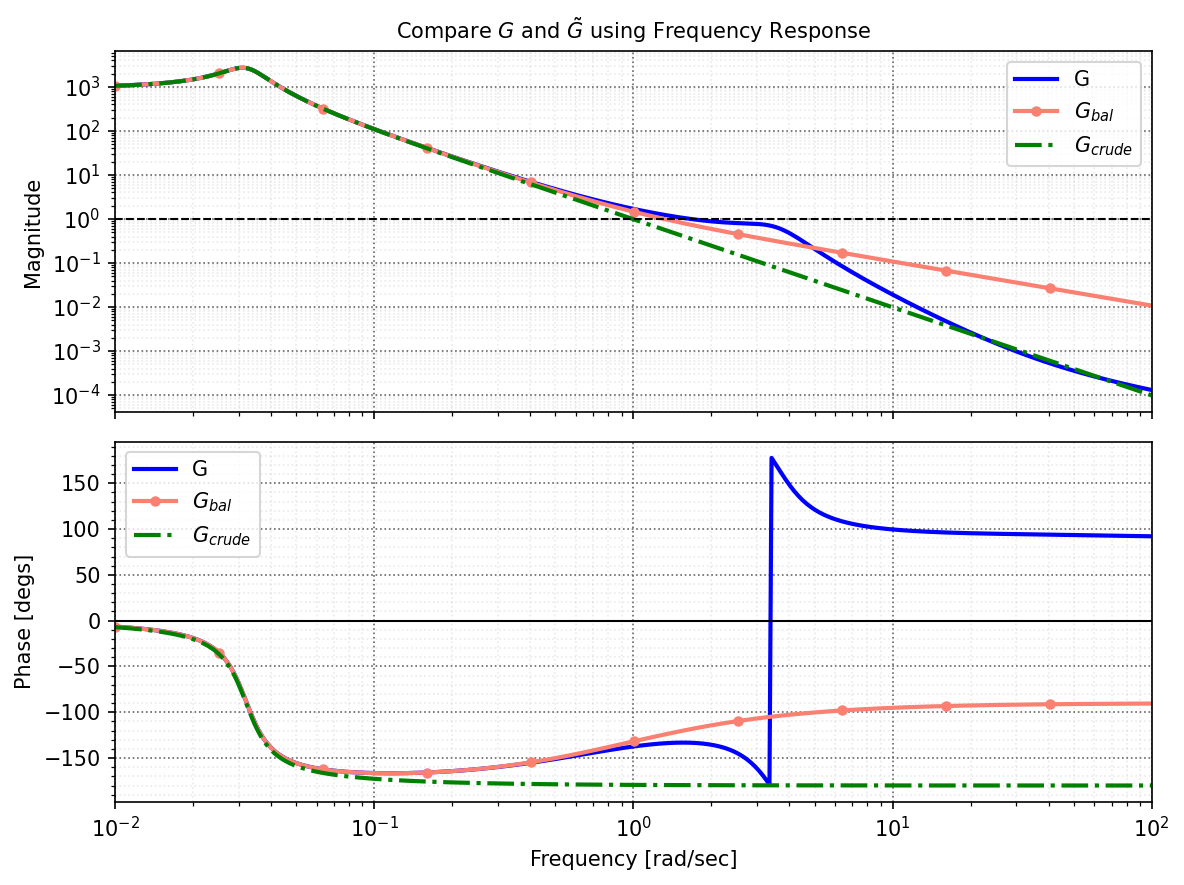

In [41]:
Npts = 500
wp = np.logspace(-2,2,Npts)
gain, phase, w = ct.frequency_response(P, wp)
if bm.SLYCOT_AVAILABLE:
    gainr, phaser, wr = ct.frequency_response(Pr, wp)
gaing, phaseg, wg = ct.frequency_response(G, wp)
gainrr, phaserr, wrr = ct.frequency_response(Prr, wp)

fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(w,gain,'b-',label='G')
if bm.SLYCOT_AVAILABLE:
    ax[0].loglog(wr,gainr,'r--',label=r'$G_{sly-bal}$')
ax[0].loglog(wg,gaing,color='salmon',ls='-',label=r'$G_{bal}$',marker='o',ms=4,markevery=int(Npts/10))
ax[0].loglog(wrr,gainrr,'g-.',label=r'$G_{crude}$')

ax[1].semilogx(w,phase*bm.R2D,'b-',label='G')
if bm.SLYCOT_AVAILABLE:
    ax[1].semilogx(wr,phaser*bm.R2D,'r--',label=r'$G_{sly-bal}$')
ax[1].semilogx(wg,phaseg*bm.R2D,color='salmon',ls='-',label=r'$G_{bal}$',marker='o',ms=4,markevery=int(Npts/10))
ax[1].semilogx(wrr,phaserr*bm.R2D,'g-.',label=r'$G_{crude}$')

ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")

ax[0].set_ylabel("Magnitude")
ax[0].set_title(r"Compare $G$ and $\tilde{G}$ using Frequency Response")
ax[0].legend()
ax[1].legend()
bm.nicegrid(ax)
plt.savefig("./figs/DP_Ex41.pdf", dpi=300)
plt.show()

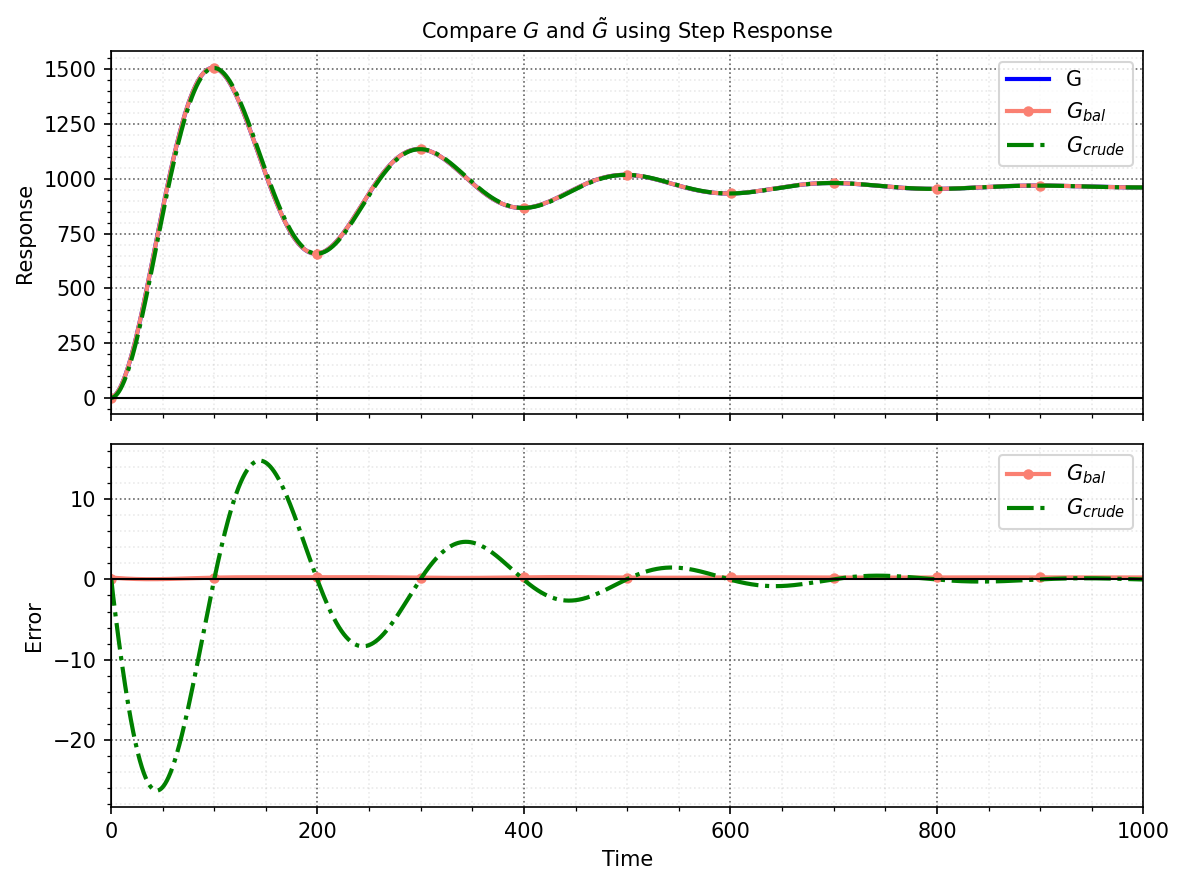

In [42]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
T = 1000
y,t = cmat.step(P,T)
Npts = len(t)
if bm.SLYCOT_AVAILABLE:
    yr,tr = cmat.step(Pr,t)
yrg,trg = cmat.step(G,t)
yrr,trr = cmat.step(Prr,t)

ax[0].plot(t,y,'b',label='G')
if bm.SLYCOT_AVAILABLE:
    ax[0].plot(tr,yr,'r--',label=r'$G_{sly-bal}$')
ax[0].plot(trg,yrg,color='salmon',ls='-',label=r'$G_{bal}$',marker='o',ms=4,markevery=int(Npts/10))
ax[0].plot(trr,yrr,'g-.',label=r'$G_{crude}$')
ax[1].set_xlabel("Time")
if bm.SLYCOT_AVAILABLE:
    ax[1].plot(t,yr-y,'r--',label=r'$G_{{sly-bal}}$')
ax[1].plot(t,yrg-y,color='salmon',ls='-',label=r'$G_{bal}$',marker='o',ms=4,markevery=int(Npts/10))
ax[1].plot(t,yrr-y,'g-.',label=r'$G_{crude}$')
ax[0].set_ylabel("Response")
ax[1].set_ylabel("Error")
ax[0].legend()
ax[1].legend()
ax[0].set_title(r"Compare $G$ and $\tilde{G}$ using Step Response")
bm.nicegrid(ax)
plt.savefig("./figs/DP_Ex42.pdf", dpi=300)
plt.show()

Hankel singular values: [ 1594.235  1112.112    0.365    0.242]
Reduced numerator coeffs: [   0.000   -0.014   -0.011]
Reduced denominator coeffs: [   1.000   -0.158   -0.055]


/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/scipy/signal/_ltisys.py:599: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  self.num, self.den = normalize(*system)


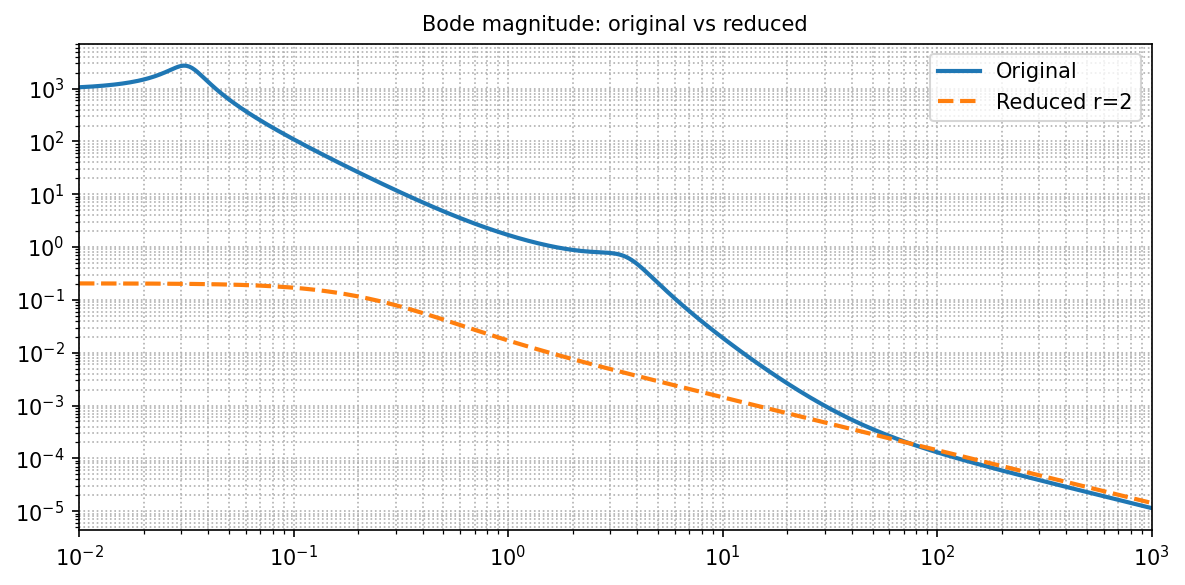

In [43]:
import numpy as np
import scipy.linalg as la
import scipy.signal as sig
import matplotlib.pyplot as plt

def balanced_truncation_from_factorized_coeffs(r=2, verbose=True):
    # build polynomials from your factorization
    a1 = 0.797; a2 = 38.8; a3 = 36.0
    p1 = np.array([1.0/a1, 1.0])     # s/a1 + 1
    p2 = np.array([-1.0/a2, 1.0])    # -s/a2 + 1
    p3 = np.array([1.0/a3, 1.0])     # s/a3 + 1
    num_poly = 964.0 * np.polymul(np.polymul(p1, p2), p3)

    b1 = 3.59; b2 = 0.032
    q1 = np.array([1.0/(b1**2), 2*0.28/b1, 1.0])
    q2 = np.array([1.0/(b2**2), 2*0.18/b2, 1.0])
    den_poly = np.polymul(q1, q2)

    A, B, C, D = sig.tf2ss(num_poly, den_poly)

    BBt = B.dot(B.T); CtC = C.T.dot(C)
    Wc = la.solve_continuous_lyapunov(A, -BBt)
    Wo = la.solve_continuous_lyapunov(A.T, -CtC)
    Wc = (Wc + Wc.T)/2
    Wo = (Wo + Wo.T)/2

    sqrtWc = la.sqrtm(Wc)
    M = (sqrtWc.dot(Wo).dot(sqrtWc))
    M = (M + M.T)/2
    U, S2, _ = la.svd(M)
    hsv = np.sqrt(S2)

    # balanced transform
    inv_sqrtWc = la.inv(sqrtWc)
    T = inv_sqrtWc.dot(U.dot(np.diag(np.sqrt(S2))))
    Ti = la.inv(T)
    A_bal = Ti.dot(A.dot(T)); B_bal = Ti.dot(B); C_bal = C.dot(T); D_bal = D.copy()

    # truncate
    Ar = A_bal[:r,:r]; Br = B_bal[:r,:]; Cr = C_bal[:,:r]; Dr = D_bal.copy()
    numr, denr = sig.ss2tf(Ar, Br, Cr, Dr)
    numr = np.asarray(numr).flatten()
    denr = np.asarray(denr).flatten()
    # normalize leading den coeff to 1
    denr = denr / denr[0]
    numr = numr / denr[0]

    if verbose:
        print("Hankel singular values:", np.round(hsv,6))
        print("Reduced numerator coeffs:", np.round(numr,6))
        print("Reduced denominator coeffs:", np.round(denr,6))

        # quick bode mag plot
        w = np.logspace(-2, 3, 400)
        _, H_full = sig.freqresp((num_poly, den_poly), w)
        _, H_red = sig.freqresp((numr, denr), w)
        plt.figure(figsize=(8,4))
        plt.loglog(w, np.abs(H_full), label='Original')
        plt.loglog(w, np.abs(H_red), '--', label=f'Reduced r={r}')
        plt.legend(); plt.grid(True, which='both', ls=':')
        plt.title('Bode magnitude: original vs reduced')
        plt.show()

    return numr, denr, hsv

# Example usage:
numr, denr, hsv = balanced_truncation_from_factorized_coeffs(r=2)

In [44]:
np.array([ 75.772418, 153.205767, 978.394966,  11.405989,   1.      ])/75.772418

array([   1.000,    2.022,   12.912,    0.151,    0.013])